In [1]:
import model
import epidemic_simulation
import survey_design
import random
import numpy as np
import scipy.stats
import matplotlib
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.cm as cm
import arviz
import cmdstanpy
from cmdstanpy import CmdStanModel

In [2]:
f_infectious, f_recovered, delay_inf, delay_recov = epidemic_simulation.delays()
transmission_rate = epidemic_simulation.transmission_rate

num_replicates = 20
model_dfs = []

reinfections = []
single_infections = []
transmission_rates = []

for _ in range(num_replicates):

    m = model.AgentModel(1000000, 50)
    m.transmission_rate = transmission_rate

    m.f_infectious = f_infectious
    m.f_recovered = f_recovered

    df = m.simulate(365)

    model_dfs.append(df)
    transmission_rates.append(m.transmission_rate)

    x = np.asarray([agent.number_of_times_infected for agent in m.all_persons])
    num_reinfected = len(x[x >= 2])
    reinfections.append(num_reinfected / m.N)
    num_infected = len(x[x == 1])
    single_infections.append(num_infected)



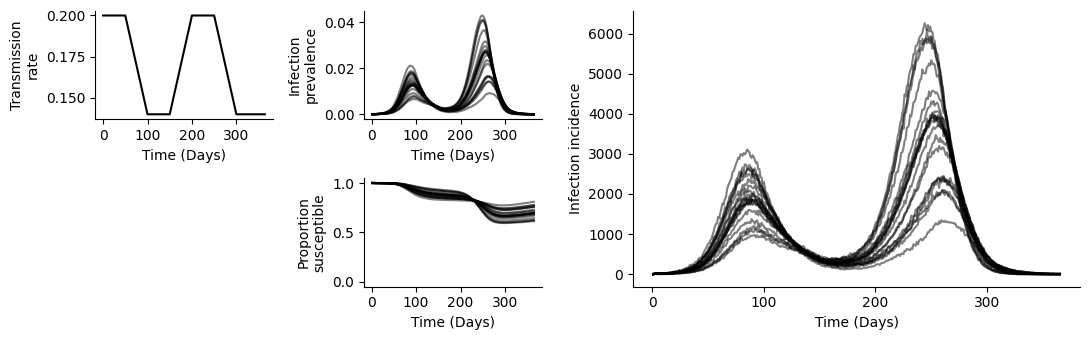

In [3]:
fig, axs = plt.subplots(ncols=4, nrows=2, figsize=(11, 3.5))

gs = axs[0, 2].get_gridspec()

for ax in axs[0:, -1]:
    ax.remove()
for ax in axs[0:, -2]:
    ax.remove()

axbig = fig.add_subplot(gs[:, 2:4])

ax = axs[0, 0]
t_days = np.arange(365)
ax.plot(t_days, [transmission_rate(t) for t in t_days], color='k')
ax.set_xlabel('Time (Days)')
ax.set_ylabel('Transmission\nrate')
ax.spines[['right', 'top']].set_visible(False)
ax.set_xticks([0, 100, 200, 300,])

ax = axs[1, 0]
ax.remove()


ax = axs[0, 1]
k = -1
for mdf in model_dfs:
    if k != 10:
        ax.plot(mdf['time'], mdf[model.InfectionStatus.INFECTED] / m.N, color='k', alpha=0.5)
    else:
        ax.plot(mdf['time'], mdf[model.InfectionStatus.INFECTED] / m.N, color='k', alpha=0.5)
    k += 1
ax.set_xlabel('Time (Days)')
ax.set_ylabel('Infection\nprevalence')
ax.spines[['right', 'top']].set_visible(False)
ax.set_xticks([0, 100, 200, 300,])

ax = axs[1, 1]
k = -1
for mdf in model_dfs:
    if k != 10:
        ax.plot(mdf['time'], mdf[model.InfectionStatus.SUSCEPTIBLE] / m.N, color='k', alpha=0.5)
    else:
        ax.plot(mdf['time'], mdf[model.InfectionStatus.SUSCEPTIBLE] / m.N, color='k', alpha=0.5)
    k += 1
ax.set_ylim(-0.05, 1.05)
ax.set_xlabel('Time (Days)')
ax.set_ylabel('Proportion\nsusceptible')
ax.spines[['right', 'top']].set_visible(False)
formatter = matplotlib.ticker.ScalarFormatter()
formatter.set_scientific(False)
ax.yaxis.set_major_formatter(formatter)
ax.set_xticks([0, 100, 200, 300,])


ax = axbig
k = -1
for mdf in model_dfs:
    if k != 10:
        ax.plot(mdf['time'], mdf['transmissions'], color='k', alpha=0.5, label=r'True infections' if k == -2 else None)
    else:
        ax.plot(mdf['time'], mdf['transmissions'], color='k', alpha=0.5, ls='-', lw=2, zorder=10, label=r'True infections' if k == 10 else None)
    k += 1

ax.set_xlabel('Time (Days)')
ax.set_ylabel('Infection incidence')
ax.spines[['right', 'top']].set_visible(False)
ax.set_xticks([0, 100, 200, 300,])

fig.set_tight_layout(True)

plt.savefig('Figure2.pdf')

plt.show()
